In [2]:
import pandas as pd
path = "Sleep_health_and_lifestyle_dataset.csv"
df = pd.read_csv(path)
df.shape

(374, 13)

In [3]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
df.sample(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
142,143,Female,38,Accountant,7.1,8,60,4,Normal,115/75,68,7000,NaN
61,62,Male,32,Doctor,6.0,6,30,8,Normal,125/80,72,5000,NaN
134,135,Male,38,Lawyer,7.3,8,60,5,Normal,130/85,68,8000,NaN
261,262,Female,45,Teacher,6.6,7,45,4,Overweight,135/90,65,6000,NaN
50,51,Male,32,Engineer,7.5,8,45,3,Normal,120/80,70,8000,NaN
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
120,121,Female,37,Accountant,7.2,8,60,4,Normal,115/75,68,7000,NaN
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
118,119,Female,37,Accountant,7.2,8,60,4,Normal,115/75,68,7000,NaN
29,30,Male,30,Doctor,7.9,7,75,6,Normal,120/80,70,8000,NaN


In [5]:
dim_person = df[['Person ID', 'Gender', 'Age', 'Occupation', 'BMI Category']].drop_duplicates(). reset_index(drop=True)
dim_person.head()

,Person ID,Gender,Age,Occupation,BMI Category
0,1,Male,27,Software Engineer,Overweight
1,2,Male,28,Doctor,Normal
2,3,Male,28,Doctor,Normal
3,4,Male,28,Sales Representative,Obese
4,5,Male,28,Sales Representative,Obese


In [6]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('No Disorder')#fillna sostituisce i valori mancanti con un valore che scelgo io.
dim_disorder = pd.DataFrame({'Sleep Disorder': df['Sleep Disorder'].unique()})#parentesi quadre indicano la creazione di un dizionario>asseganento di una chiave ad un valore.
dim_disorder['Disorder ID'] = range(1, len(dim_disorder)+1)
dim_disorder = dim_disorder[['Disorder ID', 'Sleep Disorder']]
dim_disorder.head()

,Disorder ID,Sleep Disorder
0,1,No Disorder
1,2,Sleep Apnea
2,3,Insomnia


In [9]:
# Uniamo i Disorder ID nella tabella principale
df = df.merge(dim_disorder, on='Sleep Disorder', how='left')

# Creiamo la tabella fatto
fact_sleep = df[['Person ID', 'Disorder ID', 'Sleep Duration', 'Quality of Sleep',
                 'Physical Activity Level', 'Stress Level', 'Blood Pressure',
                 'Heart Rate', 'Daily Steps']].copy()

# Aggiungiamo una chiave primaria (Fact ID)
fact_sleep.reset_index(drop=True, inplace=True)
fact_sleep.insert(0, 'Fact ID', fact_sleep.index + 1)
fact_sleep.head()

,Fact ID,Person ID,Disorder ID,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Blood Pressure,Heart Rate,Daily Steps
0,1,1,1,6.1,6,42,6,126/83,77,4200
1,2,2,1,6.2,6,60,8,125/80,75,10000
2,3,3,1,6.2,6,60,8,125/80,75,10000
3,4,4,2,5.9,4,30,8,140/90,85,3000
4,5,5,2,5.9,4,30,8,140/90,85,3000


In [18]:
dim_person.to_excel("dim_person.xlsx", index=False, engine='openpyxl')
dim_disorder.to_excel("dim_disorder.xlsx", index=False, engine='openpyxl')
fact_sleep.to_excel("fact_sleep.xlsx", index=False, engine='openpyxl')

In [16]:
#dopo aver diviso il dataset per poter fare anaisi su POWERBI ora utilizziamo il datset pulito per intero su Python.


# Rinominiamo le colonne se servono (es. spazi, ortografia)
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# Controlliamo valori mancanti
print(df.isnull().sum())

# Sostiuiamo i null con "No disorder"
df['sleep_disorder'] = df['sleep_disorder'].fillna("No Disorder")
df['sleep_disorder'] = df['sleep_disorder'].replace("None", "No Disorder") 

person_id                  0
gender                     0
age                        0
occupation                 0
sleep_duration             0
quality_of_sleep           0
physical_activity_level    0
stress_level               0
bmi_category               0
blood_pressure             0
heart_rate                 0
daily_steps                0
sleep_disorder             0
disorder_id_x              0
disorder_id_y              0
disorder_id                0
dtype: int64


In [19]:
df.head()

,person_id,gender,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,blood_pressure,heart_rate,daily_steps,sleep_disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea



# Analisi del sonno


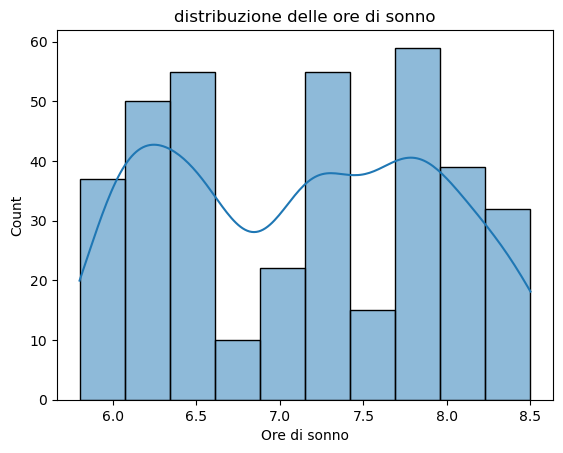

In [20]:

import seaborn as sns #libreria per grafici statistici
import matplotlib.pyplot as plt #libreria base per la visalizzazione
#distribuzione delle ore di sonno
sns.histplot(df['sleep_duration'], bins = 10, kde = True)
plt.title("distribuzione delle ore di sonno") #etichetta grafico
plt.xlabel("Ore di sonno") #etichetta asse x
plt.show()

# Relazione tra stress e qualità del sonno

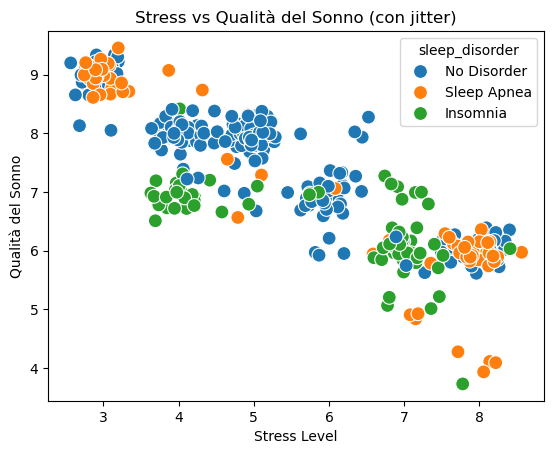

In [31]:
#jitter = tremolio o oscillazione leggera
#grafico a dispersione o scatterplot per vedere la relazione tra stresse qualità del sonnno
import numpy as np

# Aggiungiamo un po' di dispersione dei punti>in praica senza essa il grafico sarebbe poco parlante perchè tantissime persona stanno es. su punto 5 e cosi facciamo finta che siano 5.1, 5.2 ecc. per rendere il grafico più parlante
stress_jitter = df['stress_level'] + np.random.normal(0, 0.2, size=len(df))
sleep_quality_jitter = df['quality_of_sleep'] + np.random.normal(0, 0.2, size=len(df))

# Nuovo scatterplot con jitter
sns.scatterplot(data=df, x="stress_jitter", y="sleep_quality_jitter", hue="sleep_disorder", s=100)
plt.title("Stress vs Qualità del Sonno (con jitter)")
plt.xlabel("Stress Level")
plt.ylabel("Qualità del Sonno")
plt.show()

# Attività fisica per disturbo del sonno

In [ ]:
sns.barplot(x="sleep_disorder", y="physical_activity_level", data=df, )
plt.title("Media attività fisica per disturbo del sonno")
plt.ylabel("Attività fisica (media)")
plt.xlabel("Disturbo del sonno")
plt.show()

# Disturbi del sonno per occupazione

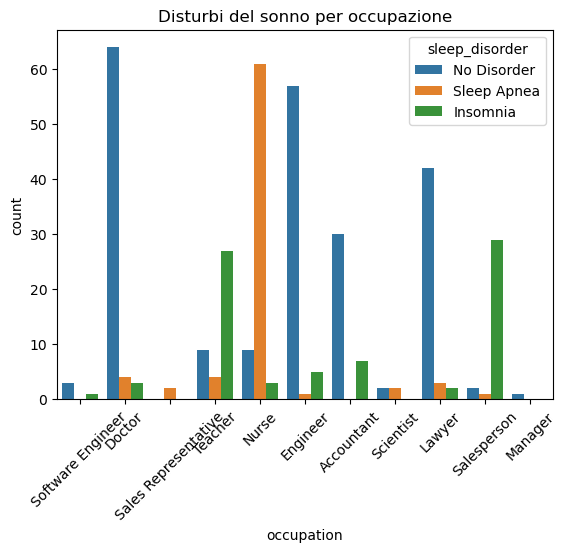

In [40]:
# Contiamo quanti soggetti hanno ciascun tipo di disturbo del sonno per ogni occupazione
sns.countplot(x="occupation", hue="sleep_disorder", data=df)
plt.xticks(rotation=45)  # Ruota le etichette dell'asse X per leggere meglio
plt.title("Disturbi del sonno per occupazione")
plt.show()

In [53]:
df.head()

,person_id,gender,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,blood_pressure,heart_rate,daily_steps,sleep_disorder,stress_jitter,sleep_quality_jitter,systolic,diastolic
0,1,1,27,9,6.1,6,42,6,3,126/83,77,4200,1,6.001467,6.210454,126,83
1,2,1,28,1,6.2,6,60,8,0,125/80,75,10000,1,8.046519,5.983876,125,80
2,3,1,28,1,6.2,6,60,8,0,125/80,75,10000,1,8.294755,6.156118,125,80
3,4,1,28,6,5.9,4,30,8,2,140/90,85,3000,2,8.137881,4.109304,140,90
4,5,1,28,6,5.9,4,30,8,2,140/90,85,3000,2,8.056404,3.931510,140,90
